In [1]:
import pandas as pd

files = {
    'Ooredoo': '../data/raw/posts_dataOOFB0.csv',
    'Orange': '../data/raw/posts_dataOrangeFB0.csv',
    'TT': '../data/raw/posts_dataTTFB0.csv'
}

dfs = []
for name, path in files.items():
    tmp = pd.read_csv(path, encoding='latin-1', on_bad_lines='skip', engine='python')
    tmp['entreprise'] = name
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)

(39376, 49)


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39376 entries, 0 to 39375
Data columns (total 49 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   39376 non-null  object 
 1   page_id              39373 non-null  float64
 2   social_id            39375 non-null  object 
 3   social_type          39373 non-null  object 
 4   creation_time        39373 non-null  object 
 5   url                  285 non-null    object 
 6   type                 1156 non-null   object 
 7   status_type          38867 non-null  object 
 8   message              36754 non-null  object 
 9   story                519 non-null    object 
 10  picture              35530 non-null  object 
 11  local_media          1 non-null      object 
 12  profile_cover        32 non-null     object 
 13  reactions            358 non-null    float64
 14  comments             38573 non-null  float64
 15  shares               33138 non-null 

In [3]:
df.isnull().sum()

id                         0
page_id                    3
social_id                  1
social_type                3
creation_time              3
url                    39091
type                   38220
status_type              509
message                 2622
story                  38857
picture                 3846
local_media            39375
profile_cover          39344
reactions              39018
comments                 803
shares                  6238
views                  38889
views_organic          39017
views_paid             39017
reach                  37035
reach_organic          21853
reach_paid             21853
likes                    804
wow                      803
sad                      803
haha                     804
angry                    805
none                     887
love                     804
thankful                 888
data                   38008
is_deleted                 5
created_at               976
updated_at               196
clicks        

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
reaction_cols = ["likes", "wow", "sad", "haha", "angry", "love", "thankful"]
for col in reaction_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['reactions'] = df[reaction_cols].sum(axis=1, min_count=1)

In [6]:
print(df['reactions'] )

0          8.0
1          1.0
2          0.0
3          1.0
4          3.0
         ...  
39371    273.0
39372    349.0
39373    240.0
39374     85.0
39375     52.0
Name: reactions, Length: 39376, dtype: float64


In [7]:
# Features simples à partir du message, avant suppression
df['message_length'] = df['message'].fillna('').apply(len)
df['has_hashtag'] = df['message'].fillna('').str.contains('#').astype(int)
df['has_link'] = df['message'].fillna('').str.contains('http|www\.').astype(int)
df['has_emoji'] = df['message'].fillna('').str.contains(
    r'[\U0001F300-\U0001FAFF\U00002600-\U000027BF]', regex=True
).astype(int)

# Suppression des colonnes (reach_organic/reach_paid conservées pour Orange)
df.drop(columns=['created_at','updated_at','is_deleted','is_real','url', 'message','story',
'picture','profile_cover','local_media','data','views_organic','views_paid','likes','wow',
'sad', 'haha', 'angry', 'love', 'thankful', 'none',
'comments_ad','views_ad','reach_ad','likes_ad','saved_ad','shares_ad','reactions_new',
'score_new','tag','type',"id","saved","commentaires"], axis=1, inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39376 entries, 0 to 39375
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   page_id              39373 non-null  float64
 1   social_id            39375 non-null  object 
 2   social_type          39373 non-null  object 
 3   creation_time        39373 non-null  object 
 4   status_type          38867 non-null  object 
 5   reactions            38573 non-null  float64
 6   comments             38573 non-null  float64
 7   shares               33138 non-null  float64
 8   views                487 non-null    float64
 9   reach                2341 non-null   float64
 10  reach_organic        17523 non-null  float64
 11  reach_paid           17523 non-null  float64
 12  clicks               17002 non-null  float64
 13  post_clicks_by_type  17002 non-null  object 
 14  entreprise           39376 non-null  object 
 15  message_length       39376 non-null 

In [12]:
# Suppression des colonnes avec plus de 90% de valeurs manquantes
missing_pct = df.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 90].index.tolist()

print(f"Colonnes supprimées (>90% manquant): {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True)

Colonnes supprimées (>90% manquant): ['views', 'reach']


In [13]:
from datetime import datetime
df = df.rename(columns={"creation_time": "timestamp"})
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%d/%m/%Y %H:%M", errors='coerce')

In [14]:
print(f"Timestamps invalides: {df['timestamp'].isna().sum()} / {len(df)}")

Timestamps invalides: 5 / 39376


In [15]:
df = df.dropna(subset=['timestamp']).reset_index(drop=True)

In [19]:
df = df.rename(columns={
    "status_type": "content_categorie",
    "social_type": "platform"
})

# page_id n'est plus utile, on le supprime puisqu'on a "entreprise"
if "competitor_id" in df.columns:
    df.drop(columns=["competitor_id"], inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39371 entries, 0 to 39370
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   social_id            39371 non-null  object        
 1   platform             39371 non-null  object        
 2   timestamp            39371 non-null  datetime64[ns]
 3   content_categorie    38864 non-null  object        
 4   reactions            38569 non-null  float64       
 5   comments             38569 non-null  float64       
 6   shares               33135 non-null  float64       
 7   reach_organic        17521 non-null  float64       
 8   reach_paid           17521 non-null  float64       
 9   clicks               17002 non-null  float64       
 10  post_clicks_by_type  17002 non-null  object        
 11  entreprise           39371 non-null  object        
 12  message_length       39371 non-null  int64         
 13  has_hashtag          39371 non-

In [21]:
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek  # 0=Lundi
df['day_name'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year
df['is_weekend'] = df['day_of_week'].isin([5, 6])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39371 entries, 0 to 39370
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   social_id            39371 non-null  object        
 1   platform             39371 non-null  object        
 2   timestamp            39371 non-null  datetime64[ns]
 3   content_categorie    38864 non-null  object        
 4   reactions            38569 non-null  float64       
 5   comments             38569 non-null  float64       
 6   shares               33135 non-null  float64       
 7   reach_organic        17521 non-null  float64       
 8   reach_paid           17521 non-null  float64       
 9   clicks               17002 non-null  float64       
 10  post_clicks_by_type  17002 non-null  object        
 11  entreprise           39371 non-null  object        
 12  message_length       39371 non-null  int64         
 13  has_hashtag          39371 non-

In [23]:
df.head()

,social_id,platform,timestamp,content_categorie,reactions,comments,shares,reach_organic,reach_paid,clicks,...,has_hashtag,has_link,has_emoji,date,hour,day_of_week,day_name,month,year,is_weekend
0,63762350267_63767210267,facebook,2008-08-08 02:32:00,added_photos,8.0,1.0,2.0,NaN,NaN,NaN,...,0,0,0,2008-08-08,2,4,Friday,8,2008,False
1,63762350267_63768670267,facebook,2008-08-08 02:37:00,added_photos,1.0,2.0,NaN,NaN,NaN,NaN,...,0,0,0,2008-08-08,2,4,Friday,8,2008,False
2,63762350267_64301765550,facebook,2008-08-08 02:59:00,added_video,0.0,0.0,NaN,NaN,NaN,NaN,...,0,0,0,2008-08-08,2,4,Friday,8,2008,False
3,63762350267_64302030550,facebook,2008-08-08 03:00:00,added_video,1.0,0.0,1.0,NaN,NaN,NaN,...,0,0,0,2008-08-08,3,4,Friday,8,2008,False
4,63762350267_64302205550,facebook,2008-08-08 03:01:00,added_video,3.0,0.0,NaN,NaN,NaN,NaN,...,0,0,0,2008-08-08,3,4,Friday,8,2008,False


In [24]:
TIME_SLOTS = {
    'night_late': {'start': '00:00', 'end': '06:00', 'id': 0},
    'early_morning': {'start': '06:00', 'end': '09:00', 'id': 1},
    'work_morning': {'start': '09:00', 'end': '12:00', 'id': 2},
    'lunch_break': {'start': '12:00', 'end': '15:00', 'id': 3},
    'work_afternoon': {'start': '15:00', 'end': '18:00', 'id': 4},
    'evening_prime': {'start': '18:00', 'end': '21:00', 'id': 5},
    'night_wind': {'start': '21:00', 'end': '23:59', 'id': 6}
}

def assign_time_slot(timestamp):
    if isinstance(timestamp, str):
        timestamp = pd.to_datetime(timestamp)
    ts_time = timestamp.time()

    for slot_name, slot_info in TIME_SLOTS.items():
        start_time = datetime.strptime(slot_info['start'], '%H:%M').time()
        end_time = datetime.strptime(slot_info['end'], '%H:%M').time()

        if slot_info['id'] < 6:
            if start_time <= ts_time < end_time:
                return slot_info['id']
        else:
            if start_time <= ts_time <= end_time:
                return slot_info['id']

    return -1

df["time_slot_id"] = df["timestamp"].apply(assign_time_slot)

In [25]:
df.head()

,social_id,platform,timestamp,content_categorie,reactions,comments,shares,reach_organic,reach_paid,clicks,...,has_link,has_emoji,date,hour,day_of_week,day_name,month,year,is_weekend,time_slot_id
0,63762350267_63767210267,facebook,2008-08-08 02:32:00,added_photos,8.0,1.0,2.0,NaN,NaN,NaN,...,0,0,2008-08-08,2,4,Friday,8,2008,False,0
1,63762350267_63768670267,facebook,2008-08-08 02:37:00,added_photos,1.0,2.0,NaN,NaN,NaN,NaN,...,0,0,2008-08-08,2,4,Friday,8,2008,False,0
2,63762350267_64301765550,facebook,2008-08-08 02:59:00,added_video,0.0,0.0,NaN,NaN,NaN,NaN,...,0,0,2008-08-08,2,4,Friday,8,2008,False,0
3,63762350267_64302030550,facebook,2008-08-08 03:00:00,added_video,1.0,0.0,1.0,NaN,NaN,NaN,...,0,0,2008-08-08,3,4,Friday,8,2008,False,0
4,63762350267_64302205550,facebook,2008-08-08 03:01:00,added_video,3.0,0.0,NaN,NaN,NaN,NaN,...,0,0,2008-08-08,3,4,Friday,8,2008,False,0


In [27]:
metrics_columns = ['reactions', 'comments', 'shares']
for col in metrics_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

if "post_clicks_by_type" in df.columns:
    df["post_clicks_by_type"] = df["post_clicks_by_type"].ffill() 

In [28]:
df['total_engagement'] = df['reactions'] + df['comments'] + df['shares']

In [29]:
df.head()

,social_id,platform,timestamp,content_categorie,reactions,comments,shares,reach_organic,reach_paid,clicks,...,has_emoji,date,hour,day_of_week,day_name,month,year,is_weekend,time_slot_id,total_engagement
0,63762350267_63767210267,facebook,2008-08-08 02:32:00,added_photos,8.0,1.0,2.0,NaN,NaN,NaN,...,0,2008-08-08,2,4,Friday,8,2008,False,0,11.0
1,63762350267_63768670267,facebook,2008-08-08 02:37:00,added_photos,1.0,2.0,0.0,NaN,NaN,NaN,...,0,2008-08-08,2,4,Friday,8,2008,False,0,3.0
2,63762350267_64301765550,facebook,2008-08-08 02:59:00,added_video,0.0,0.0,0.0,NaN,NaN,NaN,...,0,2008-08-08,2,4,Friday,8,2008,False,0,0.0
3,63762350267_64302030550,facebook,2008-08-08 03:00:00,added_video,1.0,0.0,1.0,NaN,NaN,NaN,...,0,2008-08-08,3,4,Friday,8,2008,False,0,2.0
4,63762350267_64302205550,facebook,2008-08-08 03:01:00,added_video,3.0,0.0,0.0,NaN,NaN,NaN,...,0,2008-08-08,3,4,Friday,8,2008,False,0,3.0


In [30]:
print("\n📊 ANALYSE DES PATTERNS DE PUBLICATION PAR ENTREPRISE...")
for ent in df['entreprise'].unique():
    sub = df[df['entreprise'] == ent]
    total_days = (sub['timestamp'].max() - sub['timestamp'].min()).days + 1
    print(f"\n🏢 {ent}:")
    print(f"  - Total posts: {len(sub)}")
    print(f"  - Période: {sub['timestamp'].min().date()} à {sub['timestamp'].max().date()}")
    print(f"  - Posts/jour moyen: {len(sub) / total_days:.2f}")
    print(f"  - Engagement moyen: {sub['total_engagement'].mean():.1f}")
    print(f"  - Engagement médian: {sub['total_engagement'].median():.1f}")


📊 ANALYSE DES PATTERNS DE PUBLICATION PAR ENTREPRISE...

🏢 Ooredoo:
  - Total posts: 8913
  - Période: 2008-08-08 à 2025-06-16
  - Posts/jour moyen: 1.45
  - Engagement moyen: 2090.5
  - Engagement médian: 456.0

🏢 Orange:
  - Total posts: 18321
  - Période: 2010-05-05 à 2025-06-11
  - Posts/jour moyen: 3.32
  - Engagement moyen: 1120.4
  - Engagement médian: 106.0

🏢 TT:
  - Total posts: 12137
  - Période: 2010-08-12 à 2025-06-16
  - Posts/jour moyen: 2.24
  - Engagement moyen: 1048.8
  - Engagement médian: 116.0


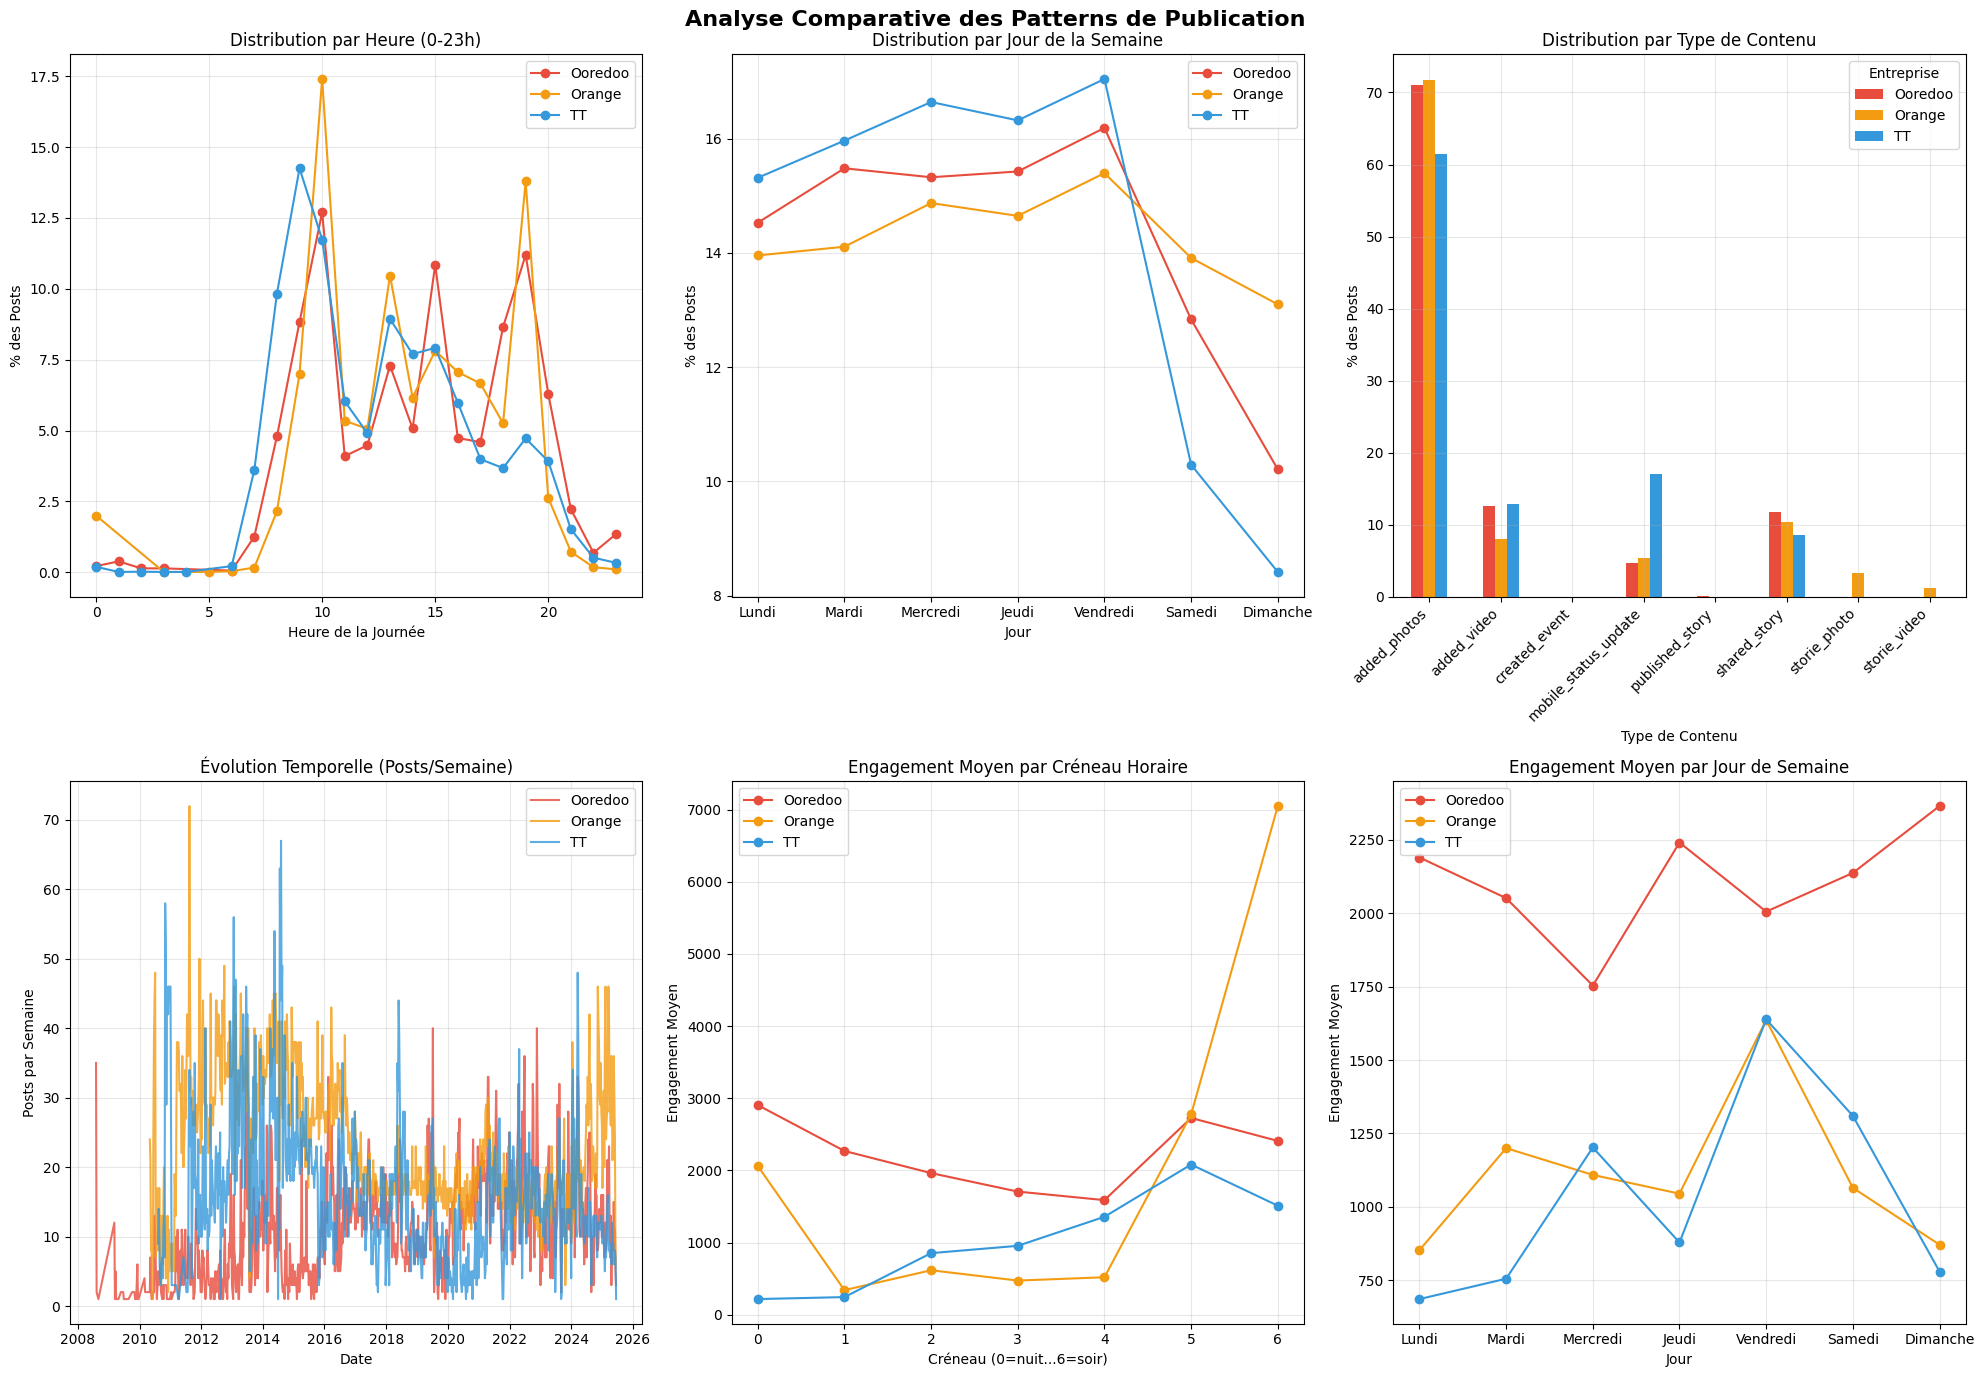

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('Analyse Comparative des Patterns de Publication', fontsize=16, fontweight='bold')

entreprises = df['entreprise'].unique()
colors = {'Ooredoo': '#e74c3c', 'Orange': '#f39c12', 'TT': '#3498db'}

# 1. Posts par heure de la journée (comparaison)
for ent in entreprises:
    sub = df[df['entreprise'] == ent]
    hourly_counts = sub.groupby('hour').size()
    hourly_pct = hourly_counts / hourly_counts.sum() * 100  # en %, pour comparer équitablement malgré volumes différents
    axes[0, 0].plot(hourly_pct.index, hourly_pct.values, marker='o', label=ent, color=colors.get(ent))
axes[0, 0].set_title('Distribution par Heure (0-23h)')
axes[0, 0].set_xlabel('Heure de la Journée')
axes[0, 0].set_ylabel('% des Posts')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Posts par jour de la semaine (comparaison)
day_map = {0: 'Lundi', 1: 'Mardi', 2: 'Mercredi', 3: 'Jeudi', 4: 'Vendredi', 5: 'Samedi', 6: 'Dimanche'}
for ent in entreprises:
    sub = df[df['entreprise'] == ent]
    daily_counts = sub.groupby('day_of_week').size()
    daily_pct = daily_counts / daily_counts.sum() * 100
    axes[0, 1].plot([day_map[d] for d in daily_pct.index], daily_pct.values, marker='o', label=ent, color=colors.get(ent))
axes[0, 1].set_title('Distribution par Jour de la Semaine')
axes[0, 1].set_xlabel('Jour')
axes[0, 1].set_ylabel('% des Posts')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Posts par type de contenu (comparaison, barres groupées)
content_pivot = df.groupby(['content_categorie', 'entreprise']).size().unstack(fill_value=0)
content_pivot_pct = content_pivot.div(content_pivot.sum(axis=0), axis=1) * 100
content_pivot_pct.plot(kind='bar', ax=axes[0, 2], color=[colors.get(c) for c in content_pivot_pct.columns])
axes[0, 2].set_title('Distribution par Type de Contenu')
axes[0, 2].set_xlabel('Type de Contenu')
axes[0, 2].set_ylabel('% des Posts')
axes[0, 2].legend(title='Entreprise')
axes[0, 2].grid(True, alpha=0.3)
plt.setp(axes[0, 2].get_xticklabels(), rotation=45, ha='right')

# 4. Évolution temporelle (posts par semaine, une ligne par entreprise)
df['week'] = df['timestamp'].dt.to_period('W')
for ent in entreprises:
    sub = df[df['entreprise'] == ent]
    weekly_counts = sub.groupby('week').size()
    axes[1, 0].plot(weekly_counts.index.to_timestamp(), weekly_counts.values, label=ent, color=colors.get(ent), alpha=0.8)
axes[1, 0].set_title('Évolution Temporelle (Posts/Semaine)')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Posts par Semaine')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Engagement moyen par créneau horaire (comparaison)
for ent in entreprises:
    sub = df[df['entreprise'] == ent]
    slot_eng = sub.groupby('time_slot_id')['total_engagement'].mean()
    axes[1, 1].plot(slot_eng.index, slot_eng.values, marker='o', label=ent, color=colors.get(ent))
axes[1, 1].set_title('Engagement Moyen par Créneau Horaire')
axes[1, 1].set_xlabel('Créneau (0=nuit...6=soir)')
axes[1, 1].set_ylabel('Engagement Moyen')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Engagement moyen par jour de semaine (comparaison)
for ent in entreprises:
    sub = df[df['entreprise'] == ent]
    day_eng = sub.groupby('day_of_week')['total_engagement'].mean()
    axes[1, 2].plot([day_map[d] for d in day_eng.index], day_eng.values, marker='o', label=ent, color=colors.get(ent))
axes[1, 2].set_title('Engagement Moyen par Jour de Semaine')
axes[1, 2].set_xlabel('Jour')
axes[1, 2].set_ylabel('Engagement Moyen')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/analyse_comparative.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
import numpy as np

print("\n INSIGHTS DÉTAILLÉS PAR ENTREPRISE:")

for ent in entreprises:
    sub = df[df['entreprise'] == ent].copy()
    print(f"\n{'='*50}")
    print(f" {ent}")
    print(f"{'='*50}")

    # Heures les plus actives
    hourly_counts = sub.groupby('hour').size()
    top_hours = hourly_counts.sort_values(ascending=False).head(3)
    print(f"\n Heures les plus actives:")
    for hour, count in top_hours.items():
        print(f"  - {hour}h: {count} posts ({count/len(sub)*100:.1f}%)")

    # Jours les plus actifs
    daily_counts = sub.groupby('day_of_week').size()
    print(f"\n Jours les plus actifs:")
    for day, count in daily_counts.sort_values(ascending=False).head(3).items():
        print(f"  - {day_map[day]}: {count} posts ({count/len(sub)*100:.1f}%)")

    # Weekend vs semaine
    weekend_posts = sub[sub['is_weekend']].shape[0]
    weekday_posts = sub[~sub['is_weekend']].shape[0]
    print(f"\n Weekend vs Semaine:")
    print(f"  - Weekend: {weekend_posts} posts ({weekend_posts/len(sub)*100:.1f}%)")
    print(f"  - Semaine: {weekday_posts} posts ({weekday_posts/len(sub)*100:.1f}%)")

    # Heures de bureau vs hors heures
    sub['is_business_hours'] = np.where((sub["hour"] > 8) & (sub["hour"] < 18), True, False)
    business_posts = sub[sub['is_business_hours']].shape[0]
    after_hours_posts = sub[~sub['is_business_hours']].shape[0]
    print(f"\n Heures de bureau (8h-18h) vs Hors heures:")
    print(f"  - Heures de bureau: {business_posts} posts ({business_posts/len(sub)*100:.1f}%)")
    print(f"  - Hors heures: {after_hours_posts} posts ({after_hours_posts/len(sub)*100:.1f}%)")

    # Performance par créneaux
    business_eng = sub[sub['is_business_hours']]['total_engagement'].mean()
    after_eng = sub[~sub['is_business_hours']]['total_engagement'].mean()
    weekend_eng = sub[sub['is_weekend']]['total_engagement'].mean()
    weekday_eng = sub[~sub['is_weekend']]['total_engagement'].mean()
    print(f"\n Performance par créneaux:")
    print(f"  - Engagement heures bureau: {business_eng:.1f}")
    print(f"  - Engagement hors heures: {after_eng:.1f}")
    print(f"  - Engagement weekend: {weekend_eng:.1f}")
    print(f"  - Engagement semaine: {weekday_eng:.1f}")


 INSIGHTS DÉTAILLÉS PAR ENTREPRISE:

 Ooredoo

 Heures les plus actives:
  - 10h: 1132 posts (12.7%)
  - 19h: 998 posts (11.2%)
  - 15h: 967 posts (10.8%)

 Jours les plus actifs:
  - Vendredi: 1443 posts (16.2%)
  - Mardi: 1380 posts (15.5%)
  - Jeudi: 1375 posts (15.4%)

 Weekend vs Semaine:
  - Weekend: 2054 posts (23.0%)
  - Semaine: 6859 posts (77.0%)

 Heures de bureau (8h-18h) vs Hors heures:
  - Heures de bureau: 5583 posts (62.6%)
  - Hors heures: 3330 posts (37.4%)

 Performance par créneaux:
  - Engagement heures bureau: 1774.3
  - Engagement hors heures: 2620.7
  - Engagement weekend: 2238.0
  - Engagement semaine: 2046.4

 Orange

 Heures les plus actives:
  - 10h: 3189 posts (17.4%)
  - 19h: 2527 posts (13.8%)
  - 13h: 1918 posts (10.5%)

 Jours les plus actifs:
  - Vendredi: 2821 posts (15.4%)
  - Mercredi: 2725 posts (14.9%)
  - Jeudi: 2684 posts (14.6%)

 Weekend vs Semaine:
  - Weekend: 4949 posts (27.0%)
  - Semaine: 13372 posts (73.0%)

 Heures de bureau (8h-18h) v

In [36]:
from datetime import timedelta

date_ranges = {}
for ent in entreprises:
    sub = df[df['entreprise'] == ent]
    start_date = sub['timestamp'].min().date()
    end_date = sub['timestamp'].max().date()
    dr = pd.date_range(start=pd.to_datetime(start_date), end=pd.to_datetime(end_date) + timedelta(days=1), freq='h')
    date_ranges[ent] = dr
    print(f"✓ {ent} — Grille temporelle: {len(dr)} heures ({start_date} à {end_date})")

✓ Ooredoo — Grille temporelle: 147769 heures (2008-08-08 à 2025-06-16)
✓ Orange — Grille temporelle: 132409 heures (2010-05-05 à 2025-06-11)
✓ TT — Grille temporelle: 130153 heures (2010-08-12 à 2025-06-16)


In [39]:
def load_and_prepare_data(files_dict):
    """
    files_dict: dict {nom_entreprise: chemin_fichier}
    Retourne le dataframe complet, nettoyé et enrichi.
    """
    dfs = []
    for name, path in files_dict.items():
        tmp = pd.read_csv(path, encoding='latin-1', on_bad_lines='skip', engine='python')
        tmp['entreprise'] = name
        dfs.append(tmp)
    df = pd.concat(dfs, ignore_index=True)

    # Reactions
    reaction_cols = ["likes", "wow", "sad", "haha", "angry", "love", "thankful"]
    for col in reaction_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['reactions'] = df[reaction_cols].sum(axis=1, min_count=1)

    # Features texte avant suppression du message
    df['message_length'] = df['message'].fillna('').apply(len)
    df['has_hashtag'] = df['message'].fillna('').str.contains('#').astype(int)
    df['has_link'] = df['message'].fillna('').str.contains(r'http|www\.').astype(int)
    df['has_emoji'] = df['message'].fillna('').str.contains(
        r'[\U0001F300-\U0001FAFF\U00002600-\U000027BF]', regex=True
    ).astype(int)

    # Suppression colonnes inutiles (reach_organic/reach_paid conservées)
    df.drop(columns=['created_at','updated_at','is_deleted','is_real','url', 'message','story',
        'picture','profile_cover','local_media','data','views_organic','views_paid','likes','wow',
        'sad', 'haha', 'angry', 'love', 'thankful', 'none',
        'comments_ad','views_ad','reach_ad','likes_ad','saved_ad','shares_ad','reactions_new',
        'score_new','tag','type',"id"], axis=1, inplace=True, errors='ignore')

    df.dropna(axis=1, how="all", inplace=True)

    # Suppression colonnes >90% manquant
    missing_pct = df.isnull().mean() * 100
    cols_to_drop = missing_pct[missing_pct > 90].index.tolist()
    df.drop(columns=cols_to_drop, inplace=True)

    df.drop(columns=["social_id"], inplace=True, errors='ignore')

    # Timestamp
    df = df.rename(columns={"creation_time": "timestamp"})
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%d/%m/%Y %H:%M", errors='coerce')
    df = df.dropna(subset=['timestamp']).reset_index(drop=True)

    # Renommage
    df = df.rename(columns={"status_type": "content_categorie", "social_type": "platform"})
    df.drop(columns=["page_id"], inplace=True, errors='ignore')

    # Features temporelles
    df['date'] = df['timestamp'].dt.date
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['day_name'] = df['timestamp'].dt.day_name()
    df['month'] = df['timestamp'].dt.month
    df['year'] = df['timestamp'].dt.year
    df['is_weekend'] = df['day_of_week'].isin([5, 6])
    df['is_business_hours'] = (df['hour'] > 8) & (df['hour'] < 18)

    # Créneaux horaires
    df["time_slot_id"] = df["timestamp"].apply(assign_time_slot)

    # Métriques finales
    for col in ['reactions', 'comments', 'shares']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    if "post_clicks_by_type" in df.columns:
        df["post_clicks_by_type"] = df["post_clicks_by_type"].ffill()

    df['total_engagement'] = df['reactions'] + df['comments'] + df['shares']

    return df

In [40]:
files = {
    'Ooredoo': '../data/raw/posts_dataOOFB0.csv',
    'Orange': '../data/raw/posts_dataOrangeFB0.csv',
    'TT': '../data/raw/posts_dataTTFB0.csv'
}
df = load_and_prepare_data(files)
df.to_csv("../data/prepared/resultPreparation.csv", index=False)
print(f"✓ Export terminé : {df.shape}")

✓ Export terminé : (39371, 25)


In [43]:
import pandas as pd
df=pd.read_csv("../data/prepared/resultPreparation.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39371 entries, 0 to 39370
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   platform             39371 non-null  object 
 1   timestamp            39371 non-null  object 
 2   content_categorie    38864 non-null  object 
 3   reactions            39371 non-null  float64
 4   comments             39371 non-null  float64
 5   shares               39371 non-null  float64
 6   reach_organic        17521 non-null  float64
 7   reach_paid           17521 non-null  float64
 8   clicks               17002 non-null  float64
 9   post_clicks_by_type  30458 non-null  object 
 10  entreprise           39371 non-null  object 
 11  message_length       39371 non-null  int64  
 12  has_hashtag          39371 non-null  int64  
 13  has_link             39371 non-null  int64  
 14  has_emoji            39371 non-null  int64  
 15  date                 39371 non-null 